# ECON 573 Project
## Job-Loss Risk Across Economic Conditions: Pre-COVID, COVID, and Post-COVID

**Research Question:** How does the structure of job-loss risk—measured as an employed-to-unemployed transition from month *t* to *t+1*—change across different economic conditions (pre-COVID, COVID, post-COVID), and which worker characteristics are most predictive in each period?

**Data:** IPUMS CPS, 2018–2023. Individual-level monthly CPS records linked via `CPSIDP`.

**Period Definitions:**
- **Pre-COVID:** January 2018 – February 2020
- **COVID:** March 2020 – December 2020
- **Post-COVID:** January 2021 – December 2023

**Outcome:** Binary indicator — worker is employed at month *t* and unemployed at month *t+1* (EU transition = 1, stays employed = 0).

**Approach:** Logistic regression estimated separately for each period, with coefficient comparison and marginal effect analysis.

---

In [9]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 30)

## 1. Data Loading & Cleaning

The CPS rotates households through 8 months of interviews (4 consecutive months, out, 4 more). `CPSIDP` uniquely identifies a person across rotation appearances, allowing us to link month-*t* to month-*t+1* records.

In [20]:
cps = pd.read_csv("/Users/xingewu/Downloads/Job Loss Data and Codebook/cps_00006.csv", dtype={
    'YEAR': int, 'SERIAL': int, 'MONTH': int,
    'CPSIDP': int, 'AGE': int, 'SEX': int, 'MARST': int,
    'EMPSTAT': int, 'OCC': int, 'IND': int,
    'CLASSWKR': int, 'UHRSWORKT': int, 'EDUC': int, 'INCWAGE': float
})

print(f"Rows loaded : {len(cps):,}")
print(f"Years       : {cps.YEAR.min()} \u2013 {cps.YEAR.max()}")
cps.head()

Rows loaded : 8,856,323
Years       : 2018 – 2023


,YEAR,SERIAL,MONTH,CPSIDP,AGE,SEX,MARST,EMPSTAT,OCC,IND,CLASSWKR,UHRSWORKT,EDUC,INCWAGE
0,2018,1,1,20161000000101,71,1,1,32,0,0,0,999,92,NaN
1,2018,1,1,20161000000102,64,2,1,36,0,0,0,999,81,NaN
2,2018,2,1,20161200000201,72,1,1,10,9140,7580,22,55,81,NaN
3,2018,2,1,20161200000202,73,2,1,36,0,0,0,999,81,NaN
4,2018,3,1,20180100000301,66,1,1,10,4920,7070,13,997,111,NaN


In [21]:
# Drop records not in universe (EMPSTAT = 0 or 1)
cps = cps[cps.EMPSTAT != 0].copy()

# Working-age adults only (16–64)
cps = cps[(cps.AGE >= 18) & (cps.AGE <= 64)].copy()

# Drop invalid CPSIDP (0 = not linkable)
cps = cps[cps.CPSIDP != 0].copy()

print(f"Rows after cleaning : {len(cps):,}")

Rows after cleaning : 5,216,371


In [22]:
# ── Recode Variables ──────────────────────────────────────────────────────────

# Employment status groups
# EMPSTAT 10,12 = employed (at work / has job not at work)
# EMPSTAT 20,21,22 = unemployed
# everything else = NILF
def emp_group(e):
    if e in (10, 12):      return 'employed'
    if e in (20, 21, 22):  return 'unemployed'
    return 'nilf'

cps['emp_group'] = cps.EMPSTAT.map(emp_group)

# Sex binary
cps['female'] = (cps.SEX == 2).astype(int)

# Marital status: married-spouse-present vs. other
cps['married'] = (cps.MARST == 1).astype(int)

# Education recode into 5 ordered categories
def educ_group(e):
    if e < 60:   return 'lt_hs'
    if e < 73:   return 'hs_diploma'
    if e < 110:  return 'some_college'
    if e < 123:  return 'bachelors'
    return 'graduate'

cps['educ_cat'] = cps.EDUC.map(educ_group)

# Age groups
cps['age_group'] = pd.cut(
    cps.AGE,
    bins=[18, 24, 34, 44, 54, 64],
    labels=['18-24', '25-34', '35-44', '45-54', '55-64'],
    include_lowest=True
)

# Class of worker
def class_group(c):
    if c in (22, 23):      return 'private'
    if c in (24, 25):      return 'nonprofit'
    if c in (26, 27, 28):  return 'government'
    if c in (13, 14):      return 'self_emp'
    return 'other'

cps['worker_class'] = cps.CLASSWKR.map(class_group)

# Part-time: usual hours < 35 (999 = hours vary, exclude)
cps['part_time'] = ((cps.UHRSWORKT > 0) & (cps.UHRSWORKT < 35)).astype(int)

# Calendar date key for sorting
cps['ym'] = cps.YEAR * 100 + cps.MONTH

print("Recode complete. Employment group distribution:")
print(cps.emp_group.value_counts())

Recode complete. Employment group distribution:
emp_group
employed      3781119
nilf          1266178
unemployed     169074
Name: count, dtype: int64


In [23]:
cps.head(15)

,YEAR,SERIAL,MONTH,CPSIDP,AGE,SEX,MARST,EMPSTAT,OCC,IND,CLASSWKR,UHRSWORKT,EDUC,INCWAGE,emp_group,female,married,educ_cat,age_group,worker_class,part_time,ym
1,2018,1,1,20161000000102,64,2,1,36,0,0,0,999,81,NaN,nilf,1,1,some_college,55-64,other,0,201801
5,2018,3,1,20180100000302,61,2,1,10,350,8270,22,997,111,NaN,employed,1,1,bachelors,55-64,private,0,201801
8,2018,9,1,20171000000401,52,2,4,10,5700,8290,27,40,73,NaN,employed,1,0,some_college,45-54,government,0,201801
11,2018,9,1,20171000000404,19,2,6,10,5240,7590,22,40,73,NaN,employed,1,0,some_college,18-24,private,0,201801
12,2018,10,1,20171000000601,56,2,4,10,3255,8190,25,40,111,NaN,employed,1,0,bachelors,55-64,nonprofit,0,201801
13,2018,10,1,20171000000602,22,2,6,10,4040,8680,22,30,81,NaN,employed,1,0,some_college,18-24,private,1,201801
14,2018,11,1,20170100000901,23,2,6,10,3255,8190,27,40,124,NaN,employed,1,0,graduate,18-24,government,0,201801
15,2018,11,1,20170100000902,24,2,6,10,3255,8190,27,40,124,NaN,employed,1,0,graduate,18-24,government,0,201801
16,2018,12,1,20170100001001,59,2,1,10,5700,9370,27,55,111,NaN,employed,1,1,bachelors,55-64,government,0,201801
17,2018,12,1,20170100001002,53,1,1,10,6840,470,22,58,81,NaN,employed,0,1,some_college,45-54,private,0,201801


---
## 2. Constructing the EU Transition Panel

We link each employed person at month *t* to their employment status at month *t+1*.
CPS months-in-sample rotate: a household interviewed in month *m* of year *y* is next observed in month *m+1*. `CPSIDP` encodes this. We match on `CPSIDP` and verify the next record is exactly one calendar month later.

In [24]:
# ── Build Month-to-Month Links ────────────────────────────────────────────────

cps = cps.sort_values(['CPSIDP', 'ym']).reset_index(drop=True)

# Shift within-person to get next-month status
cps['ym_next']   = cps.groupby('CPSIDP')['ym'].shift(-1)
cps['empg_next'] = cps.groupby('CPSIDP')['emp_group'].shift(-1)

# Compute the expected next YM
def next_ym(ym):
    year, month = divmod(int(ym), 100)
    if month == 12:
        return (year + 1) * 100 + 1
    return year * 100 + (month + 1)

cps['ym_expected_next'] = cps['ym'].apply(next_ym)
valid_link = (cps['ym_next'] == cps['ym_expected_next'])

# Keep only employed at t with a valid consecutive t+1 link
panel = cps[
    (cps.emp_group == 'employed') & valid_link
].copy()

# EU transition: 1 = unemployed next month, 0 = still employed
panel['eu_transition'] = (
    (panel.emp_group == 'employed') &
    (panel.empg_next == 'unemployed')
).astype(int)

# Drop transitions to NILF (different economic meaning than layoff)
panel = panel[panel.empg_next.isin(['employed', 'unemployed'])].copy()

print(f"Panel observations  : {len(panel):,}")
print(f"EU transitions      : {panel.eu_transition.sum():,}  ({panel.eu_transition.mean()*100:.2f}%)")
panel[['YEAR', 'MONTH', 'emp_group', 'empg_next', 'eu_transition']].head(5)

Panel observations  : 2,211,374
EU transitions      : 25,216  (1.14%)


,YEAR,MONTH,emp_group,empg_next,eu_transition
8929,2018,1,employed,employed,0
8931,2018,1,employed,employed,0
8937,2018,1,employed,employed,0
8939,2018,1,employed,employed,0
8943,2018,1,employed,employed,0


---
## 3. Period Assignment & Descriptive Statistics

In [25]:
def assign_period(ym):
    if ym < 202003:   return 'Pre-COVID'
    if ym <= 202012:  return 'COVID'
    return 'Post-COVID'

panel['period'] = panel['ym'].apply(assign_period)
panel['period'] = pd.Categorical(
    panel['period'],
    categories=['Pre-COVID', 'COVID', 'Post-COVID'],
    ordered=True
)

print("Observations by period:")
print(panel.groupby('period', observed=True).agg(
    N=('eu_transition', 'count'),
    EU_count=('eu_transition', 'sum'),
    EU_rate=('eu_transition', 'mean')
).assign(EU_rate=lambda d: d.EU_rate.map('{:.4f}'.format)))

Observations by period:
                  N  EU_count EU_rate
period                               
Pre-COVID    928079      8562  0.0092
COVID        275613      7304  0.0265
Post-COVID  1007682      9350  0.0093


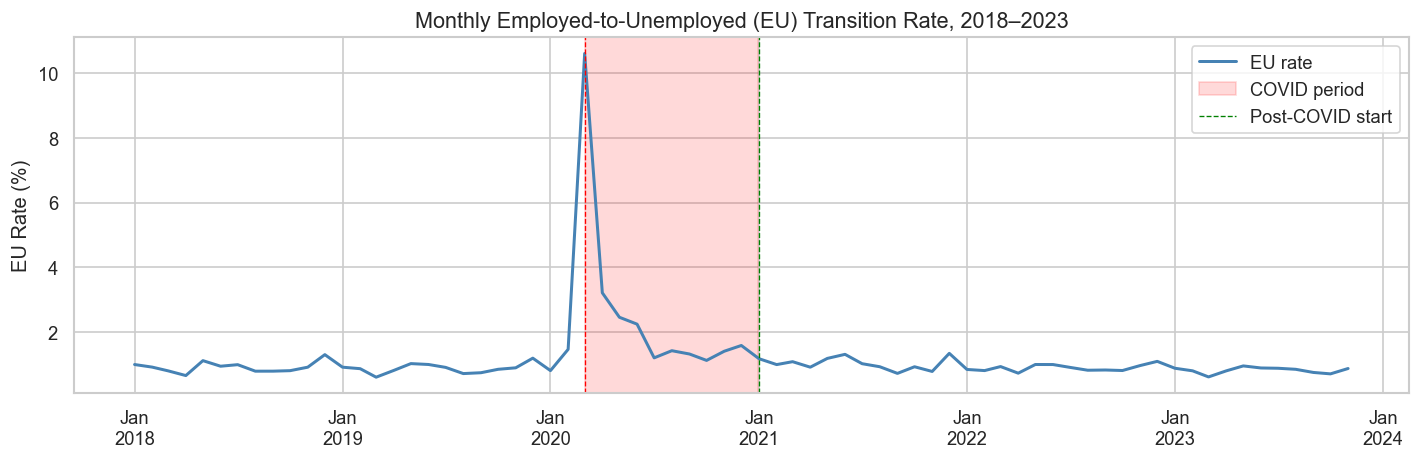

In [26]:
# Figure 1: Monthly EU Transition Rate Over Time 
monthly = (
    panel.groupby('ym')['eu_transition']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'eu_rate', 'count': 'n'})
    .reset_index()
)
monthly['date'] = pd.to_datetime(
    monthly['ym'].astype(str), format='%Y%m'
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['date'], monthly['eu_rate'] * 100,
        color='steelblue', linewidth=1.8, label='EU rate')

covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2020-12-31')
ax.axvspan(covid_start, covid_end, alpha=0.15, color='red', label='COVID period')
ax.axvline(covid_start, color='red', linestyle='--', linewidth=0.8)
ax.axvline(pd.Timestamp('2021-01-01'), color='green', linestyle='--',
           linewidth=0.8, label='Post-COVID start')

ax.set_title('Monthly Employed-to-Unemployed (EU) Transition Rate, 2018\u20132023', fontsize=13)
ax.set_ylabel('EU Rate (%)')
ax.set_xlabel('')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
plt.tight_layout()
plt.show()

In [27]:
# Table 1: EU Rate by Worker Characteristics & Period 

def eu_by_var(var, label_map=None):
    tbl = (
        panel.groupby(['period', var], observed=True)['eu_transition']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'EU Rate', 'count': 'N'})
        .unstack('period')
    )
    for p in ['Pre-COVID', 'COVID', 'Post-COVID']:
        if ('EU Rate', p) in tbl.columns:
            tbl[('EU Rate', p)] = tbl[('EU Rate', p)].map('{:.4f}'.format)
    if label_map:
        tbl.index = tbl.index.map(label_map)
    return tbl

print("=== EU Rate by Education ===")
display(eu_by_var('educ_cat'))

print("\n=== EU Rate by Age Group ===")
display(eu_by_var('age_group'))

print("\n=== EU Rate by Sex ===")
display(eu_by_var('female', {0: 'Male', 1: 'Female'}))

print("\n=== EU Rate by Worker Class ===")
display(eu_by_var('worker_class'))

print("\n=== EU Rate by Part-Time Status ===")
display(eu_by_var('part_time', {0: 'Full-time', 1: 'Part-time'}))

=== EU Rate by Education ===


EU Rate                            N                   
period       Pre-COVID   COVID Post-COVID Pre-COVID   COVID Post-COVID
educ_cat                                                              
bachelors       0.0060  0.0187     0.0062    231194   72555     264014
graduate        0.0047  0.0125     0.0045    130728   43996     158585
hs_diploma      0.0213  0.0504     0.0208     23796    5957      23290
lt_hs           0.0185  0.0439     0.0202     35018    8482      34589
some_college    0.0107  0.0327     0.0111    507343  144623     527204


=== EU Rate by Age Group ===


EU Rate                            N                  
period    Pre-COVID   COVID Post-COVID Pre-COVID  COVID Post-COVID
age_group                                                         
18-24        0.0198  0.0506     0.0200     94241  25569     101762
25-34        0.0095  0.0265     0.0103    210491  60580     228078
35-44        0.0081  0.0227     0.0082    218504  66622     246289
45-54        0.0074  0.0222     0.0071    215572  63888     228483
55-64        0.0071  0.0250     0.0066    189271  58954     203070


=== EU Rate by Sex ===


EU Rate                            N                   
period Pre-COVID   COVID Post-COVID Pre-COVID   COVID Post-COVID
female                                                          
Male      0.0097  0.0247     0.0099    484951  144789     528597
Female    0.0087  0.0285     0.0086    443128  130824     479085


=== EU Rate by Worker Class ===


EU Rate                            N                   
period       Pre-COVID   COVID Post-COVID Pre-COVID   COVID Post-COVID
worker_class                                                          
government      0.0066  0.0213     0.0062    110668   34441     119409
nonprofit       0.0055  0.0119     0.0040     26868    9132      31175
other           0.0077  0.1184     0.0097     52834   21356      64835
private         0.0100  0.0175     0.0098    649264  182941     694023
self_emp        0.0092  0.0265     0.0104     88445   27743      98240


=== EU Rate by Part-Time Status ===


EU Rate                            N                   
period    Pre-COVID   COVID Post-COVID Pre-COVID   COVID Post-COVID
part_time                                                          
Full-time    0.0078  0.0221     0.0077    808981  242227     885281
Part-time    0.0191  0.0583     0.0205    119098   33386     122401

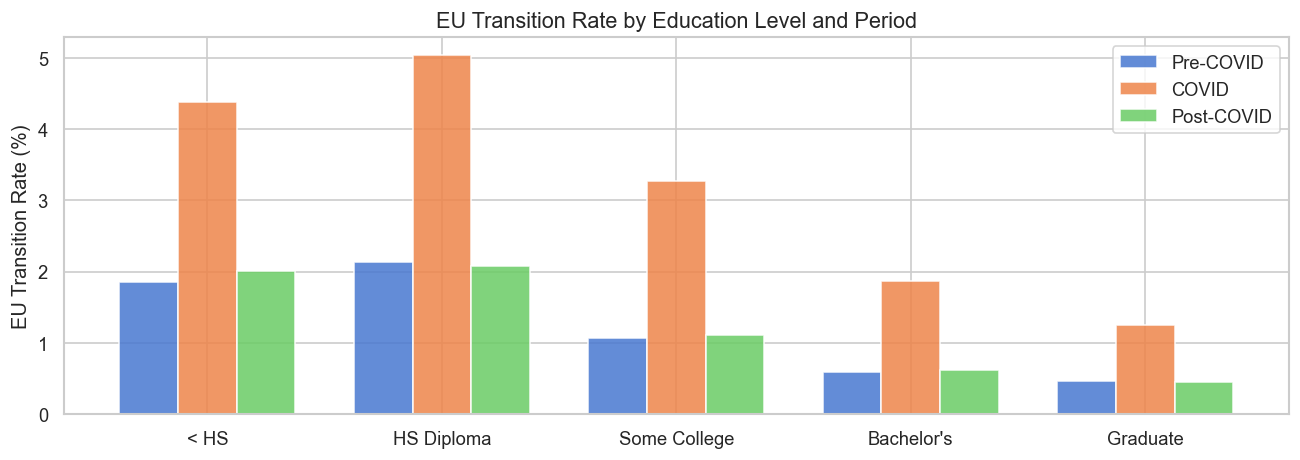

In [29]:
# Figure 2: EU Rate by Education & Period (grouped bar)

educ_order  = ['lt_hs', 'hs_diploma', 'some_college', 'bachelors', 'graduate']
educ_labels = ['< HS', 'HS Diploma', 'Some College', "Bachelor's", 'Graduate']
colors = ['#4878d0', '#ee854a', '#6acc65']

eu_educ = (
    panel.groupby(['period', 'educ_cat'], observed=True)['eu_transition']
    .mean().reset_index()
)
eu_educ['educ_cat'] = pd.Categorical(eu_educ['educ_cat'], categories=educ_order, ordered=True)
eu_educ = eu_educ.sort_values(['educ_cat', 'period'])

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(educ_order))
width = 0.25

for i, period in enumerate(['Pre-COVID', 'COVID', 'Post-COVID']):
    sub = eu_educ[eu_educ.period == period].set_index('educ_cat').reindex(educ_order)
    ax.bar(x + i * width, sub['eu_transition'] * 100, width,
           label=period, color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(educ_labels)
ax.set_ylabel('EU Transition Rate (%)')
ax.set_title('EU Transition Rate by Education Level and Period', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Logistic Regression: Job-Loss Risk Models

We estimate the following logistic regression **separately for each period**:

$$\Pr(\text{EU}_{i,t+1} = 1 \mid X_{i,t}) = \Lambda\left(\beta_0 + \beta_1 \text{female} + \beta_2 \text{age} + \beta_3 \text{married} + \beta_4 \text{educ} + \beta_5 \text{part\_time} + \beta_6 \text{class\_wkr}\right)$$

where $\Lambda(\cdot)$ is the logistic function. Coefficients across periods reveal how the *structure* of risk changed, not just its level.

In [30]:
# Feature Engineering for Regression

# Dummies: education (reference = hs_diploma)
educ_dummies = pd.get_dummies(panel['educ_cat'], prefix='educ', drop_first=False)
educ_dummies = educ_dummies.drop(columns=['educ_hs_diploma'], errors='ignore')

# Dummies: worker class (reference = private)
class_dummies = pd.get_dummies(panel['worker_class'], prefix='cls', drop_first=False)
class_dummies = class_dummies.drop(columns=['cls_private'], errors='ignore')

# Dummies: age group (reference = 35-44)
age_dummies = pd.get_dummies(panel['age_group'], prefix='age', drop_first=False)
age_dummies = age_dummies.drop(columns=['age_35-44'], errors='ignore')

model_df = pd.concat([
    panel[['eu_transition', 'period', 'female', 'married', 'part_time', 'YEAR', 'ym']].reset_index(drop=True),
    educ_dummies.reset_index(drop=True),
    class_dummies.reset_index(drop=True),
    age_dummies.reset_index(drop=True)
], axis=1).dropna()

feature_cols = [
    c for c in model_df.columns
    if c not in ('eu_transition', 'period', 'YEAR', 'ym')
]

# Convert boolean dummies to int
for c in feature_cols:
    model_df[c] = model_df[c].astype(float)

print(f"Model dataset rows : {len(model_df):,}")
print(f"Features           : {feature_cols}")

Model dataset rows : 2,211,374
Features           : ['female', 'married', 'part_time', 'educ_bachelors', 'educ_graduate', 'educ_lt_hs', 'educ_some_college', 'cls_government', 'cls_nonprofit', 'cls_other', 'cls_self_emp', 'age_18-24', 'age_25-34', 'age_45-54', 'age_55-64']


In [31]:
# Fit Statsmodels Logit per Period
# Using statsmodels for p-values, standard errors, and marginal effects

results = {}
marginal_effects = {}

for period in ['Pre-COVID', 'COVID', 'Post-COVID']:
    sub = model_df[model_df.period == period]
    X = sm.add_constant(sub[feature_cols])
    y = sub['eu_transition']

    logit_model = sm.Logit(y, X)
    res = logit_model.fit(maxiter=200, disp=False)
    results[period] = res
    marginal_effects[period] = res.get_margeff()

    n       = len(sub)
    eu_rate = y.mean()
    print(f"\n{'='*60}")
    print(f"Period: {period}  |  N={n:,}  |  EU rate={eu_rate:.4f}")
    print(f"{'='*60}")
    print(res.summary2().tables[1])


Period: Pre-COVID  |  N=928,079  |  EU rate=0.0092
                      Coef.  Std.Err.          z          P>|z|    [0.025  \
const             -3.867227  0.053331 -72.513900   0.000000e+00 -3.971753   
female            -0.170211  0.022496  -7.566266   3.841058e-14 -0.214303   
married           -0.587813  0.024907 -23.600701  3.790737e-123 -0.636629   
part_time          0.709402  0.026707  26.562073  1.862904e-155  0.657056   
educ_bachelors    -0.907297  0.053816 -16.859334   8.959284e-64 -1.012774   
educ_graduate     -1.024926  0.062533 -16.390080   2.251482e-60 -1.147489   
educ_lt_hs         0.146286  0.060850   2.404033   1.621531e-02  0.027022   
educ_some_college -0.477204  0.047511 -10.044114   9.752038e-24 -0.570324   
cls_government    -0.122159  0.039975  -3.055895   2.243899e-03 -0.200508   
cls_nonprofit     -0.264239  0.084120  -3.141198   1.682581e-03 -0.429111   
cls_other         -0.273804  0.051475  -5.319139   1.042597e-07 -0.374693   
cls_self_emp       0.070

In [32]:
# Table 2: Average Marginal Effects Summary 

ame_rows = []
for period, me in marginal_effects.items():
    df_me = me.summary_frame().copy()
    df_me['period']   = period
    df_me['variable'] = df_me.index
    ame_rows.append(df_me)

ame_all   = pd.concat(ame_rows)
ame_pivot = ame_all.pivot(index='variable', columns='period', values='dy/dx')

# Express as percentage-point changes
ame_pivot_pct = (ame_pivot * 100).round(4)

print("Average Marginal Effects (percentage-point change in EU probability)")
display(ame_pivot_pct)

Average Marginal Effects (percentage-point change in EU probability)


period,COVID,Post-COVID,Pre-COVID
variable,,,
age_18-24,0.6616,0.2576,0.2461
age_25-34,0.1444,0.0983,0.0239
age_45-54,-0.0694,-0.1201,-0.0780
age_55-64,0.0364,-0.2459,-0.1525
cls_government,1.1059,-0.1349,-0.1111
cls_nonprofit,-0.1908,-0.4836,-0.2404
cls_other,5.0570,-0.0167,-0.2491
cls_self_emp,1.2594,0.1609,0.0644
educ_bachelors,-1.7294,-0.7208,-0.8254


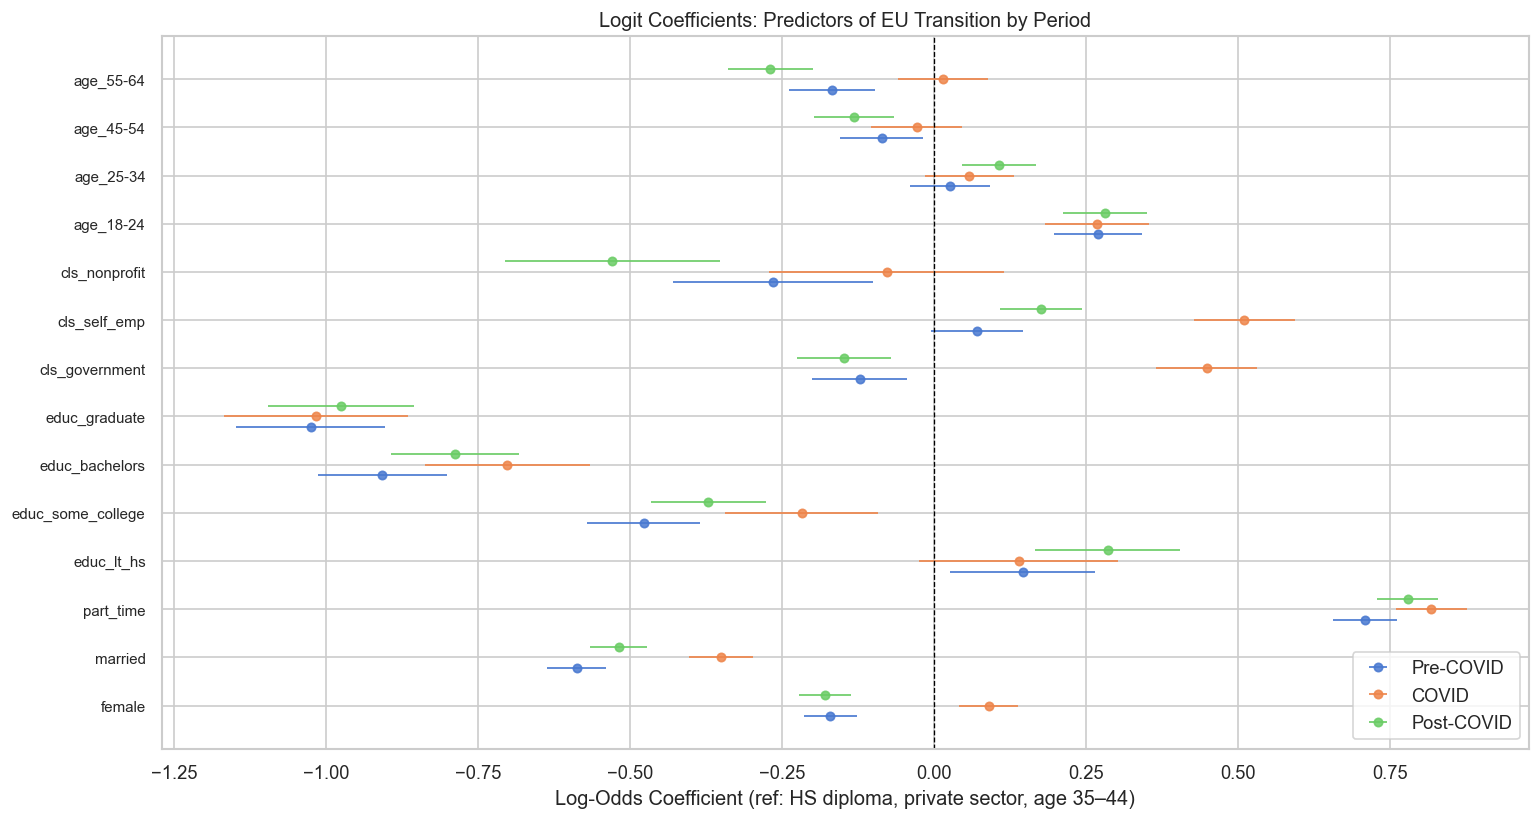

In [33]:
# Figure 3: Coefficient Plot — Key Variables Across Periods

key_vars = [
    'female', 'married', 'part_time',
    'educ_lt_hs', 'educ_some_college', 'educ_bachelors', 'educ_graduate',
    'cls_government', 'cls_self_emp', 'cls_nonprofit',
    'age_18-24', 'age_25-34', 'age_45-54', 'age_55-64'
]

colors  = ['#4878d0', '#ee854a', '#6acc65']
offsets = [-0.22, 0, 0.22]

fig, ax = plt.subplots(figsize=(13, 7))

for j, period in enumerate(['Pre-COVID', 'COVID', 'Post-COVID']):
    res = results[period]
    coefs, cis, labels = [], [], []
    for v in key_vars:
        if v in res.params.index:
            coefs.append(res.params[v])
            ci = res.conf_int().loc[v]
            cis.append((ci.iloc[0], ci.iloc[1]))
            labels.append(v)

    y_pos   = np.arange(len(labels)) + offsets[j]
    xerr_lo = [c - ci[0] for c, ci in zip(coefs, cis)]
    xerr_hi = [ci[1] - c for c, ci in zip(coefs, cis)]

    ax.errorbar(
        coefs, y_pos,
        xerr=[xerr_lo, xerr_hi],
        fmt='o', color=colors[j],
        markersize=5, linewidth=1.2,
        label=period, alpha=0.85
    )

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Log-Odds Coefficient (ref: HS diploma, private sector, age 35\u201344)')
ax.set_title('Logit Coefficients: Predictors of EU Transition by Period', fontsize=12)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

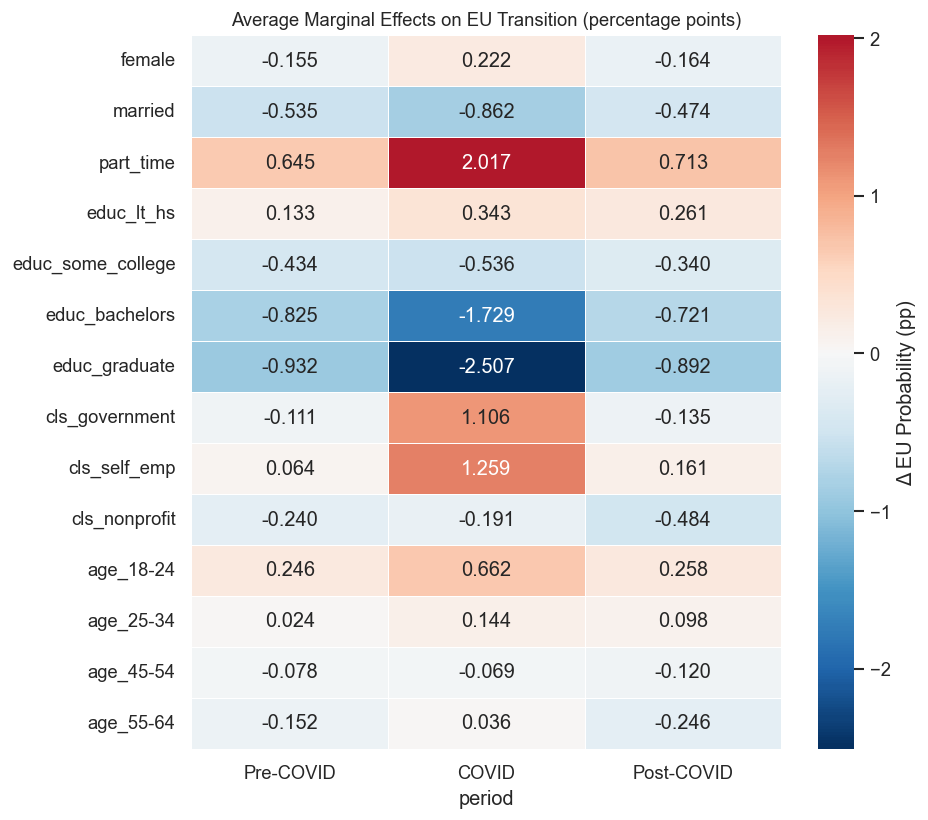

In [34]:
# Figure 4: Average Marginal Effects Heatmap

ame_heat = ame_pivot_pct.loc[
    [v for v in key_vars if v in ame_pivot_pct.index],
    ['Pre-COVID', 'COVID', 'Post-COVID']
]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    ame_heat.astype(float),
    annot=True, fmt='.3f',
    cmap='RdBu_r', center=0,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': '\u0394 EU Probability (pp)'}
)
ax.set_title('Average Marginal Effects on EU Transition (percentage points)', fontsize=11)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## 5. Predictive Performance (sklearn)

We assess out-of-sample predictive ability of the logistic model in each period using an 80/20 train-test split. Given severe class imbalance (EU transitions are rare), we report ROC-AUC alongside accuracy.

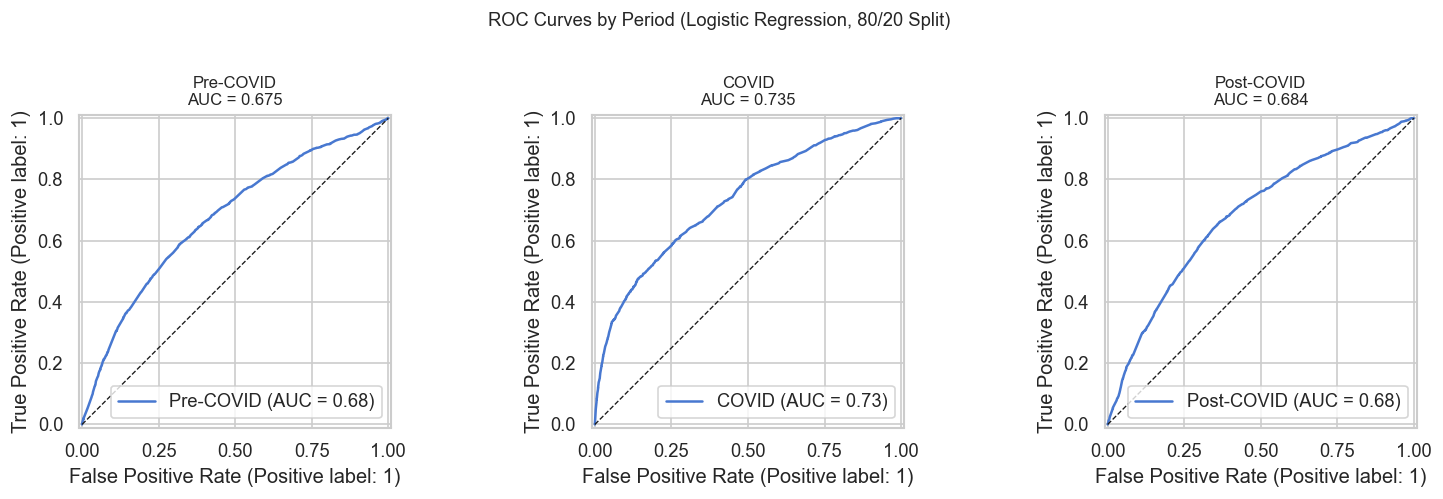


Predictive Performance Summary:


,Period,Accuracy,ROC-AUC,N_test
0,Pre-COVID,0.6313,0.6753,185616
1,COVID,0.7720,0.7347,55123
2,Post-COVID,0.6715,0.6838,201537


In [35]:
# Sklearn Logit: Train/Test Performance by Period

perf_rows = []
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, period in zip(axes, ['Pre-COVID', 'COVID', 'Post-COVID']):
    sub = model_df[model_df.period == period]
    X   = sub[feature_cols].astype(float)
    y   = sub['eu_transition']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('logit', LogisticRegression(
            max_iter=500, class_weight='balanced', random_state=42
        ))
    ])
    pipe.fit(X_train, y_train)

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    perf_rows.append({'Period': period, 'Accuracy': round(acc, 4), 'ROC-AUC': round(auc, 4), 'N_test': len(y_test)})

    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name=period)
    ax.set_title(f'{period}\nAUC = {auc:.3f}', fontsize=10)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

plt.suptitle('ROC Curves by Period (Logistic Regression, 80/20 Split)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print("\nPredictive Performance Summary:")
display(pd.DataFrame(perf_rows))

---
## 5b. Enhanced ML Evaluation

Adds **PR-AUC** (the right metric when EU rate ~1%), **Top-k precision**, **Brier score**, a **time-based chronological split**, and **calibration curves**.

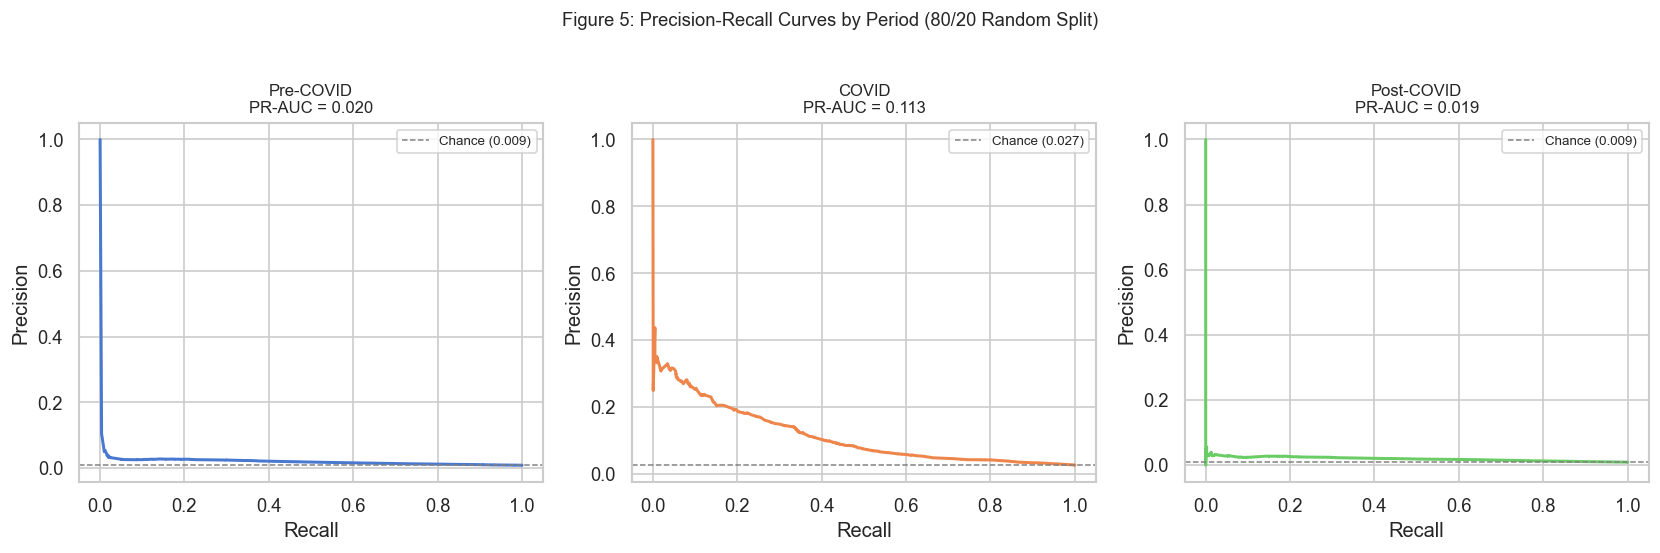

TIME-BASED (CHRONOLOGICAL) SPLIT
  Pre-COVID  : train ym <= 201912, test ym >= 202001
  COVID      : train ym <= 202006, test ym >  202006
  Post-COVID : train YEAR <= 2022, test YEAR == 2023
  Pre-COVID: N_train=860,600, N_test=67,479, EU=0.0114, ROC=0.681, PR-AUC=0.025
  COVID: N_train=100,302, N_test=175,311, EU=0.0135, ROC=0.648, PR-AUC=0.024
  Post-COVID: N_train=697,709, N_test=309,973, EU=0.0083, ROC=0.680, PR-AUC=0.018

Table 3: Extended Performance Summary (all splits):


,Period,Split,ROC-AUC,PR-AUC,Brier,Top-1% Prec,Top-5% Prec,N_test
0,COVID,Random,0.7347,0.1127,0.19581,0.2613,0.1520,55123
1,COVID,Time-Based,0.6477,0.0237,0.14280,NaN,0.0322,175311
2,Post-COVID,Random,0.6838,0.0193,0.22208,0.0318,0.0278,201537
3,Post-COVID,Time-Based,0.6802,0.0180,0.22336,NaN,0.0254,309973
4,Pre-COVID,Random,0.6753,0.0203,0.22401,0.0323,0.0278,185616
5,Pre-COVID,Time-Based,0.6808,0.0252,0.22545,NaN,0.0332,67479


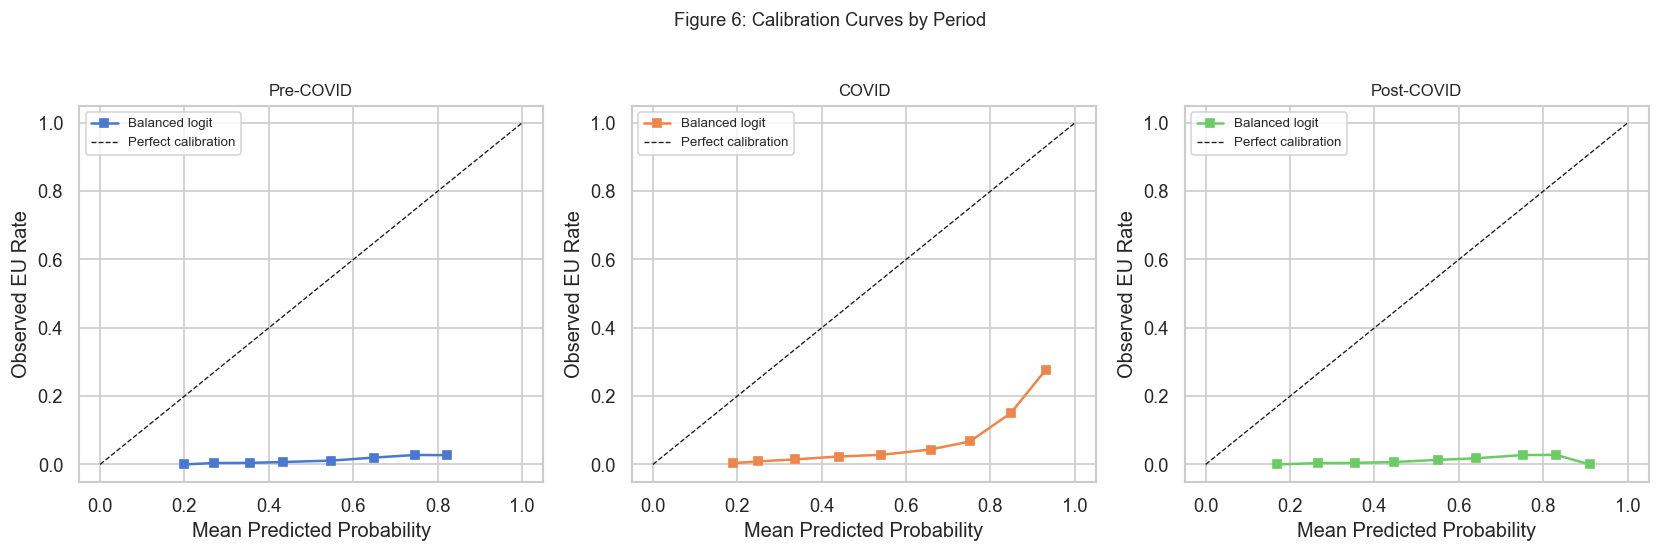

In [36]:
# Section 5b: Enhanced ML Metrics
# PR-AUC, Top-k precision, Brier score, time-based split, calibration.

from sklearn.metrics import (
    average_precision_score, brier_score_loss, precision_recall_curve
)
from sklearn.calibration import calibration_curve

# ── Recover ym + YEAR from panel (works regardless of what cell 16 stored) ──
_meta = panel[['ym', 'YEAR']].reset_index(drop=True)
model_df['ym']   = _meta.loc[model_df.index, 'ym'].values
model_df['YEAR'] = _meta.loc[model_df.index, 'YEAR'].values

# Drop AGE from feature_cols if present (collinear with age group dummies)
feature_cols_use = [c for c in feature_cols if c not in ('AGE', 'ym', 'YEAR')]

PERIODS = ['Pre-COVID', 'COVID', 'Post-COVID']
COLORS  = ['#4878d0', '#ee854a', '#6acc65']

# ─── (A) Random split: PR curves + extended metrics ──────────────────────────
perf_ext = []
fig_pr, axes_pr = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, period, color in zip(axes_pr, PERIODS, COLORS):
    sub  = model_df[model_df.period == period]
    X, y = sub[feature_cols_use].astype(float), sub['eu_transition']
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('logit',  LogisticRegression(max_iter=500,
                      class_weight='balanced', random_state=42))])
    pipe.fit(X_tr, y_tr)
    y_prob  = pipe.predict_proba(X_te)[:, 1]
    pr_auc  = average_precision_score(y_te, y_prob)
    roc_auc = roc_auc_score(y_te, y_prob)
    brier   = brier_score_loss(y_te, y_prob)
    k1 = max(1, int(0.01 * len(y_te)))
    k5 = max(1, int(0.05 * len(y_te)))
    order = np.argsort(y_prob)[::-1]
    top1_prec = float(y_te.iloc[order[:k1]].mean())
    top5_prec = float(y_te.iloc[order[:k5]].mean())
    perf_ext.append({'Period': period, 'Split': 'Random',
                     'ROC-AUC': round(roc_auc, 4), 'PR-AUC': round(pr_auc, 4),
                     'Brier': round(brier, 5),
                     'Top-1% Prec': round(top1_prec, 4),
                     'Top-5% Prec': round(top5_prec, 4), 'N_test': len(y_te)})
    prec_c, rec_c, _ = precision_recall_curve(y_te, y_prob)
    ax.plot(rec_c, prec_c, color=color, linewidth=1.8)
    ax.axhline(y_te.mean(), color='grey', linestyle='--',
               linewidth=0.9, label=f'Chance ({y_te.mean():.3f})')
    ax.set_title(f'{period}\nPR-AUC = {pr_auc:.3f}', fontsize=10)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.legend(fontsize=8)

plt.suptitle('Figure 5: Precision-Recall Curves by Period (80/20 Random Split)',
             fontsize=11, y=1.02)
plt.tight_layout(); plt.show()

# ─── (B) Time-based chronological split ──────────────────────────────────────
print('=' * 65)
print('TIME-BASED (CHRONOLOGICAL) SPLIT')
print('  Pre-COVID  : train ym <= 201912, test ym >= 202001')
print('  COVID      : train ym <= 202006, test ym >  202006')
print('  Post-COVID : train YEAR <= 2022, test YEAR == 2023')
print('=' * 65)

for period in PERIODS:
    sub = model_df[model_df.period == period].copy()
    if period == 'Pre-COVID':
        train_mask = sub['ym'] <= 201912
        test_mask  = sub['ym'] >= 202001
    elif period == 'COVID':
        train_mask = sub['ym'] <= 202006
        test_mask  = sub['ym'] >  202006
    else:
        train_mask = sub['YEAR'] <= 2022
        test_mask  = sub['YEAR'] == 2023
    X_tr = sub.loc[train_mask, feature_cols_use].astype(float)
    y_tr = sub.loc[train_mask, 'eu_transition']
    X_te = sub.loc[test_mask,  feature_cols_use].astype(float)
    y_te = sub.loc[test_mask,  'eu_transition']
    if len(y_te) < 20 or y_te.sum() == 0:
        print(f'  {period}: too few test events ({int(y_te.sum())}), skipping.')
        continue
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('logit',  LogisticRegression(max_iter=500,
                      class_weight='balanced', random_state=42))])
    pipe.fit(X_tr, y_tr)
    y_prob  = pipe.predict_proba(X_te)[:, 1]
    pr_auc  = average_precision_score(y_te, y_prob)
    roc_auc = roc_auc_score(y_te, y_prob)
    brier   = brier_score_loss(y_te, y_prob)
    k5      = max(1, int(0.05 * len(y_te)))
    top5_p  = float(y_te.iloc[np.argsort(y_prob)[::-1][:k5]].mean())
    perf_ext.append({'Period': period, 'Split': 'Time-Based',
                     'ROC-AUC': round(roc_auc, 4), 'PR-AUC': round(pr_auc, 4),
                     'Brier': round(brier, 5), 'Top-1% Prec': None,
                     'Top-5% Prec': round(top5_p, 4), 'N_test': len(y_te)})
    print(f'  {period}: N_train={len(y_tr):,}, N_test={len(y_te):,}, '
          f'EU={y_te.mean():.4f}, ROC={roc_auc:.3f}, PR-AUC={pr_auc:.3f}')

print('\nTable 3: Extended Performance Summary (all splits):')
display(pd.DataFrame(perf_ext).sort_values(['Period','Split']).reset_index(drop=True))

# ─── (C) Calibration curves ──────────────────────────────────────────────────
fig_cal, axes_cal = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, period, color in zip(axes_cal, PERIODS, COLORS):
    sub  = model_df[model_df.period == period]
    X, y = sub[feature_cols_use].astype(float), sub['eu_transition']
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('logit',  LogisticRegression(max_iter=500,
                      class_weight='balanced', random_state=42))])
    pipe.fit(X_tr, y_tr)
    y_prob = pipe.predict_proba(X_te)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_te, y_prob, n_bins=10)
    ax.plot(mean_pred, frac_pos, 's-', color=color,
            linewidth=1.5, markersize=5, label='Balanced logit')
    ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Perfect calibration')
    ax.set_title(f'{period}', fontsize=10)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Observed EU Rate')
    ax.legend(fontsize=8)

plt.suptitle('Figure 6: Calibration Curves by Period', fontsize=11, y=1.02)
plt.tight_layout(); plt.show()


---
## 5c. Additional ML Classifiers (LDA, QDA, Decision Tree, Random Forest, Gradient Boosting, SVM, KNN)

We apply six additional classification methods to the same 80/20 stratified train-test split used in Section 5.
All models are evaluated using ROC-AUC and PR-AUC, reported separately for each period.
For SVM and KNN, we subsample 30,000 training observations due to computational constraints

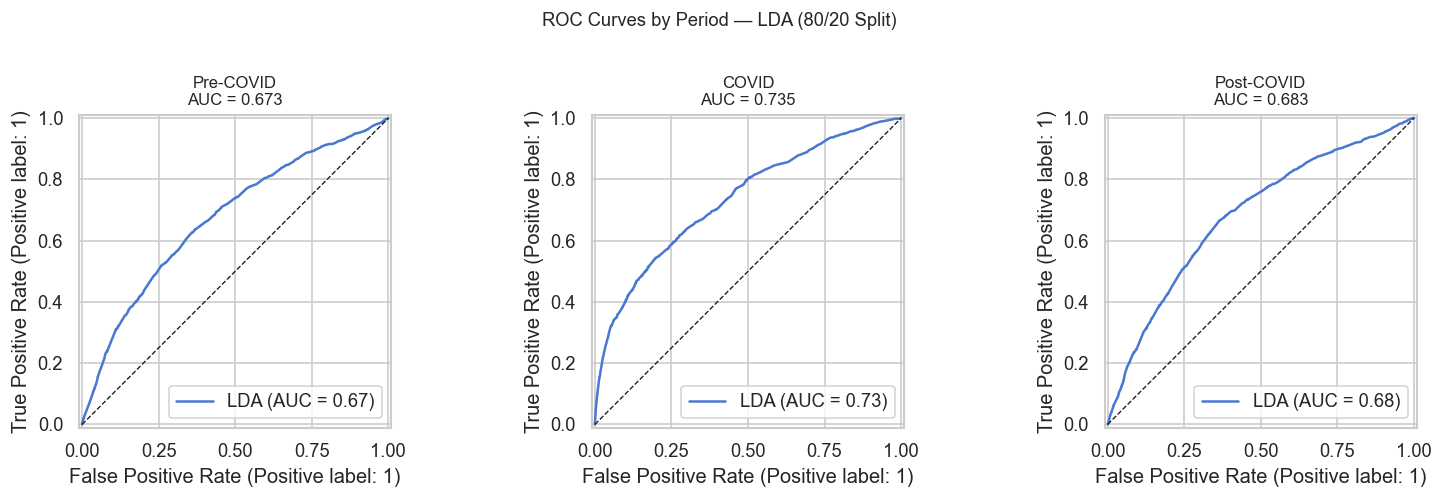


LDA Performance Summary:


,Period,Model,ROC-AUC,PR-AUC,N_test
0,Pre-COVID,LDA,0.6733,0.0193,185616
1,COVID,LDA,0.7346,0.1130,55123
2,Post-COVID,LDA,0.6829,0.0191,201537


In [37]:
# Section 5c — LDA (Linear Discriminant Analysis)
# LDA finds the linear combination of features that best separates job-losers
# from non-losers by modeling each class as a Gaussian with a shared covariance.
# It is a classical statistical classifier closely related to logistic regression
# but makes stronger distributional assumptions.

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import average_precision_score, roc_auc_score, RocCurveDisplay

lda_rows = []
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, period in zip(axes, ['Pre-COVID', 'COVID', 'Post-COVID']):
    sub  = model_df[model_df.period == period]
    X    = sub[feature_cols_use].astype(float)
    y    = sub['eu_transition']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Pipeline: scale first, then fit LDA
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lda',    LinearDiscriminantAnalysis())
    ])
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    auc    = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    lda_rows.append({'Period': period, 'Model': 'LDA',
                     'ROC-AUC': round(auc, 4), 'PR-AUC': round(pr_auc, 4),
                     'N_test': len(y_test)})

    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name='LDA')
    ax.set_title(f'{period}\nAUC = {auc:.3f}', fontsize=10)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

plt.suptitle('ROC Curves by Period — LDA (80/20 Split)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print('\nLDA Performance Summary:')
display(pd.DataFrame(lda_rows))

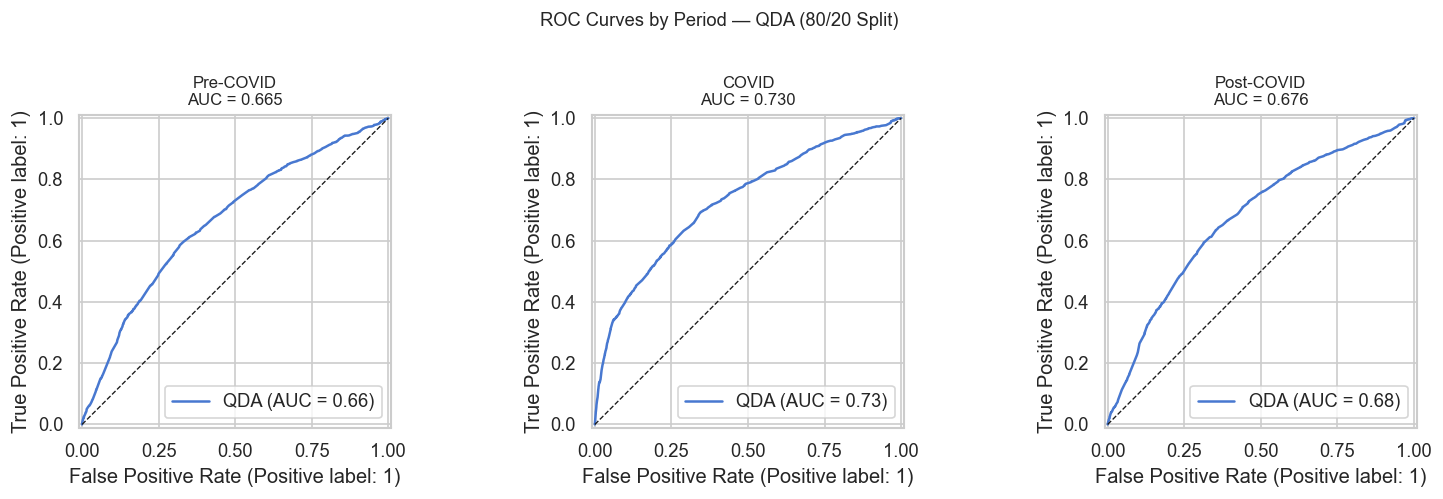


QDA Performance Summary:


,Period,Model,ROC-AUC,PR-AUC,N_test
0,Pre-COVID,QDA,0.6649,0.0184,185616
1,COVID,QDA,0.7302,0.1033,55123
2,Post-COVID,QDA,0.6759,0.0183,201537


In [38]:
# Section 5c — QDA (Quadratic Discriminant Analysis)
# QDA extends LDA by allowing each class to have its own covariance matrix,
# enabling curved (quadratic) decision boundaries. This is more flexible than
# LDA but can struggle when features are highly collinear or when one class
# has very few observations — both of which apply here.
# reg_param=0.5 adds regularization to stabilize the covariance estimates
# and prevent singular matrix errors from the many dummy variable columns.

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda_rows = []
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, period in zip(axes, ['Pre-COVID', 'COVID', 'Post-COVID']):
    sub  = model_df[model_df.period == period]
    X    = sub[feature_cols_use].astype(float)
    y    = sub['eu_transition']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('qda',    QuadraticDiscriminantAnalysis(reg_param=0.5))
    ])
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    auc    = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    qda_rows.append({'Period': period, 'Model': 'QDA',
                     'ROC-AUC': round(auc, 4), 'PR-AUC': round(pr_auc, 4),
                     'N_test': len(y_test)})

    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name='QDA')
    ax.set_title(f'{period}\nAUC = {auc:.3f}', fontsize=10)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

plt.suptitle('ROC Curves by Period — QDA (80/20 Split)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print('\nQDA Performance Summary:')
display(pd.DataFrame(qda_rows))

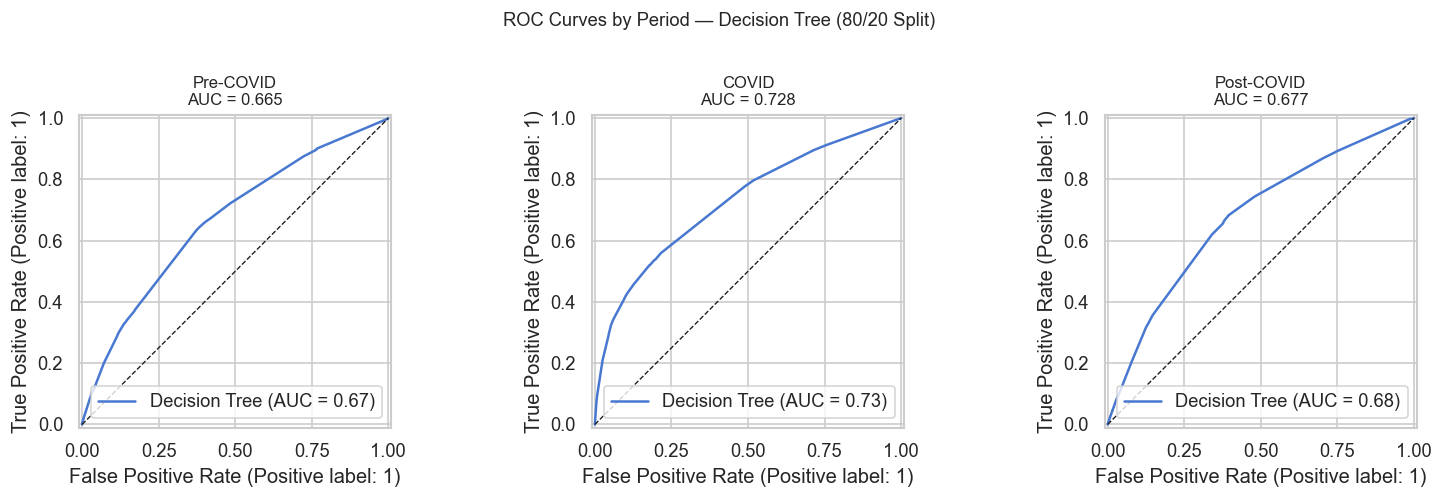


Decision Tree Performance Summary:


,Period,Model,ROC-AUC,PR-AUC,N_test
0,Pre-COVID,Decision Tree,0.6653,0.0178,185616
1,COVID,Decision Tree,0.7278,0.1018,55123
2,Post-COVID,Decision Tree,0.6767,0.0177,201537


In [39]:
# Section 5c — Decision Tree
# A decision tree splits the data into branches based on feature thresholds,
# like a flowchart: "Is age 18-24? If yes, is the person part-time? If yes,
# predict job loss." Each split tries to best separate job-losers from non-losers.
# class_weight='balanced' tells the tree to up-weight the rare job-loss cases
# so it doesn't just learn to always predict "no job loss."
# max_depth=5 limits how deep the tree grows — without this limit, the tree
# would memorize the training data perfectly but fail on new data (overfitting).
# Trees do not require scaling so no StandardScaler is used here.

from sklearn.tree import DecisionTreeClassifier

dt_rows = []
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, period in zip(axes, ['Pre-COVID', 'COVID', 'Post-COVID']):
    sub  = model_df[model_df.period == period]
    X    = sub[feature_cols_use].astype(float)
    y    = sub['eu_transition']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    dt = DecisionTreeClassifier(
        max_depth=5, class_weight='balanced', random_state=42
    )
    dt.fit(X_train, y_train)
    y_proba = dt.predict_proba(X_test)[:, 1]

    auc    = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    dt_rows.append({'Period': period, 'Model': 'Decision Tree',
                    'ROC-AUC': round(auc, 4), 'PR-AUC': round(pr_auc, 4),
                    'N_test': len(y_test)})

    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name='Decision Tree')
    ax.set_title(f'{period}\nAUC = {auc:.3f}', fontsize=10)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

plt.suptitle('ROC Curves by Period — Decision Tree (80/20 Split)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print('\nDecision Tree Performance Summary:')
display(pd.DataFrame(dt_rows))

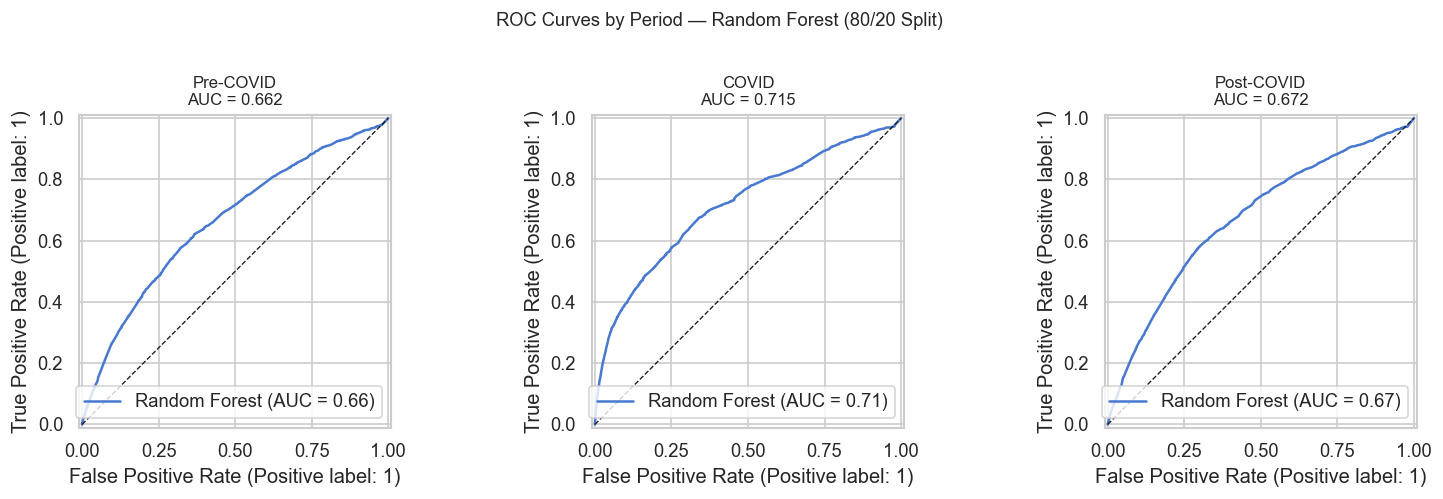


Random Forest Performance Summary:


,Period,Model,ROC-AUC,PR-AUC,N_test
0,Pre-COVID,Random Forest,0.6622,0.0190,185616
1,COVID,Random Forest,0.7149,0.1029,55123
2,Post-COVID,Random Forest,0.6716,0.0193,201537


In [40]:
# Section 5c — Random Forest
# A random forest builds many decision trees (here, 200), each trained on a
# random subset of the data and a random subset of features. It then averages
# their predicted probabilities. This "ensemble" approach dramatically reduces
# overfitting compared to a single tree and is typically the strongest
# tree-based method for structured data.
# n_jobs=-1 uses all available CPU cores to speed up training.

from sklearn.ensemble import RandomForestClassifier

rf_rows = []
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, period in zip(axes, ['Pre-COVID', 'COVID', 'Post-COVID']):
    sub  = model_df[model_df.period == period]
    X    = sub[feature_cols_use].astype(float)
    y    = sub['eu_transition']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    rf = RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=42, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_proba = rf.predict_proba(X_test)[:, 1]

    auc    = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    rf_rows.append({'Period': period, 'Model': 'Random Forest',
                    'ROC-AUC': round(auc, 4), 'PR-AUC': round(pr_auc, 4),
                    'N_test': len(y_test)})

    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name='Random Forest')
    ax.set_title(f'{period}\nAUC = {auc:.3f}', fontsize=10)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

plt.suptitle('ROC Curves by Period — Random Forest (80/20 Split)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print('\nRandom Forest Performance Summary:')
display(pd.DataFrame(rf_rows))

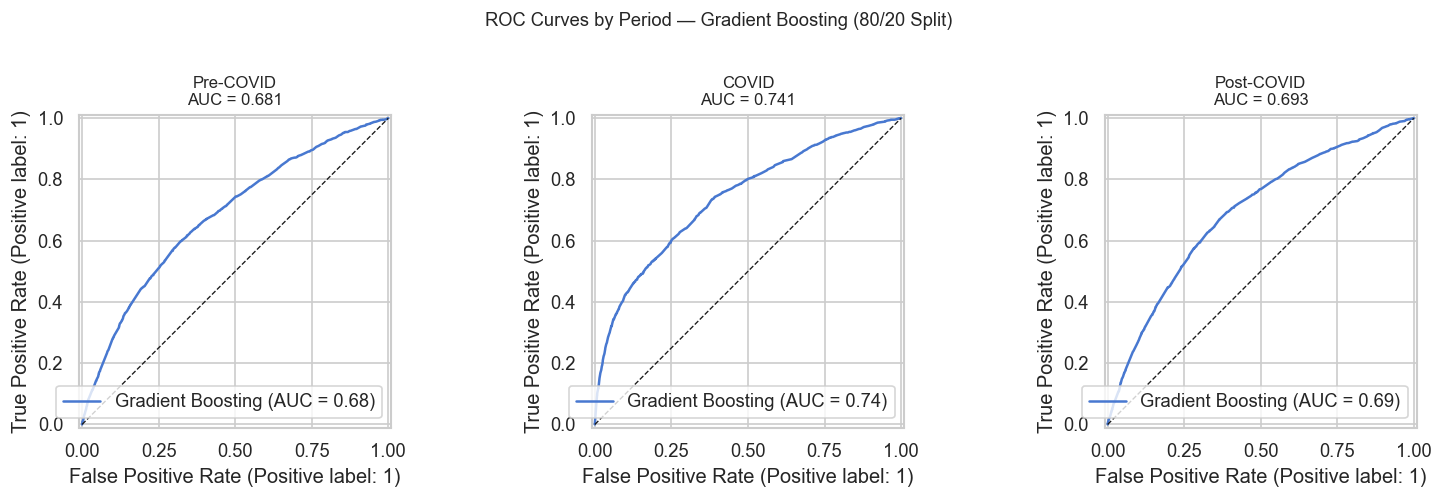


Gradient Boosting Performance Summary:


,Period,Model,ROC-AUC,PR-AUC,N_test
0,Pre-COVID,Gradient Boosting,0.6806,0.0204,185616
1,COVID,Gradient Boosting,0.7413,0.1122,55123
2,Post-COVID,Gradient Boosting,0.6926,0.0205,201537


In [41]:
# Section 5c — Gradient Boosting
# Gradient boosting also builds trees sequentially, but unlike random forest
# each new tree specifically focuses on correcting the errors the previous
# trees made. This "boosting" strategy often achieves the best predictive
# performance of any tree-based method.
# max_depth=3 keeps each individual tree shallow — they are meant to be
# weak learners that improve incrementally, not deep memorizers.
# subsample=0.8 means each tree sees a random 80% of training rows,
# which adds regularization and reduces overfitting.

from sklearn.ensemble import GradientBoostingClassifier

gb_rows = []
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, period in zip(axes, ['Pre-COVID', 'COVID', 'Post-COVID']):
    sub  = model_df[model_df.period == period]
    X    = sub[feature_cols_use].astype(float)
    y    = sub['eu_transition']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    gb = GradientBoostingClassifier(
        n_estimators=200, max_depth=3,
        subsample=0.8, random_state=42
    )
    gb.fit(X_train, y_train)
    y_proba = gb.predict_proba(X_test)[:, 1]

    auc    = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    gb_rows.append({'Period': period, 'Model': 'Gradient Boosting',
                    'ROC-AUC': round(auc, 4), 'PR-AUC': round(pr_auc, 4),
                    'N_test': len(y_test)})

    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name='Gradient Boosting')
    ax.set_title(f'{period}\nAUC = {auc:.3f}', fontsize=10)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

plt.suptitle('ROC Curves by Period — Gradient Boosting (80/20 Split)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print('\nGradient Boosting Performance Summary:')
display(pd.DataFrame(gb_rows))

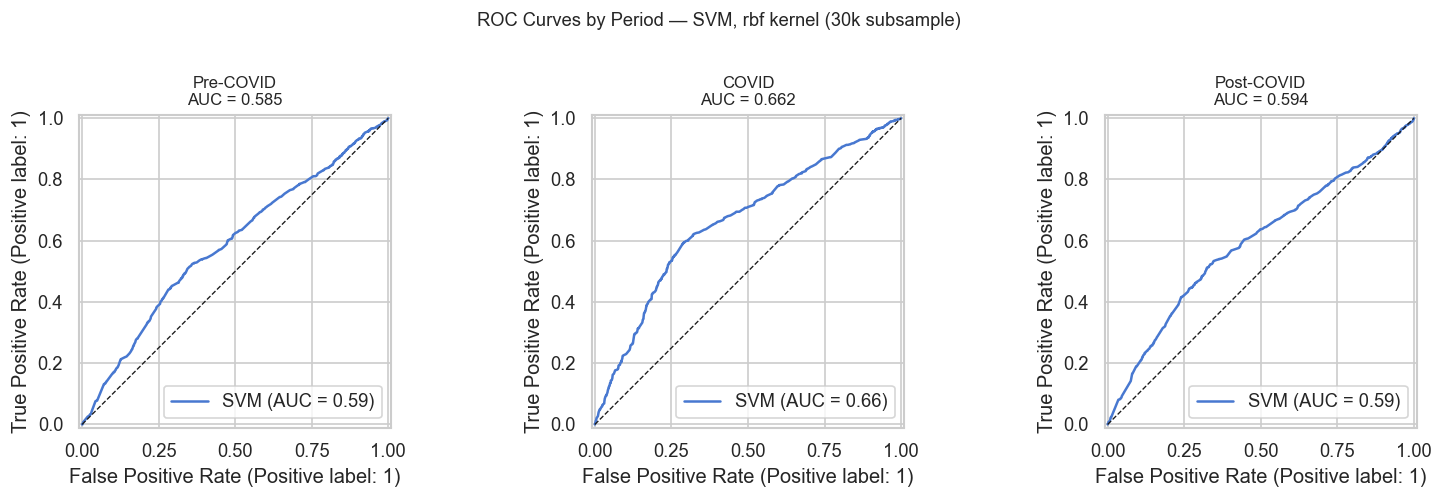


SVM Performance Summary:


,Period,Model,ROC-AUC,PR-AUC,N_test
0,Pre-COVID,SVM (subsample 30k),0.5851,0.0126,185616
1,COVID,SVM (subsample 30k),0.6622,0.0504,55123
2,Post-COVID,SVM (subsample 30k),0.5935,0.0141,201537


In [42]:
# Section 5c — SVM (Support Vector Machine)
# SVM finds the decision boundary that maximally separates the two classes
# in a transformed feature space. The 'rbf' (radial basis function) kernel
# allows non-linear boundaries — meaning it can detect complex patterns
# that a straight line could not separate.
# class_weight='balanced' compensates for the ~1% job-loss minority class.
# probability=True enables predicted probabilities (needed for AUC).
#
# IMPORTANT: SVM scales as O(n²) with training size — on 100k+ rows it
# becomes extremely slow. We therefore subsample 30,000 training observations
# per period. This is standard practice for SVM on large datasets and is
# noted as a limitation.

from sklearn.svm import SVC

svm_rows = []
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, period in zip(axes, ['Pre-COVID', 'COVID', 'Post-COVID']):
    sub  = model_df[model_df.period == period]
    X    = sub[feature_cols_use].astype(float)
    y    = sub['eu_transition']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Subsample training set to 30,000 rows for computational feasibility
    if len(X_train) > 30000:
        subsample_idx = X_train.sample(n=30000, random_state=42).index
        X_train_sub = X_train.loc[subsample_idx]
        y_train_sub = y_train.loc[subsample_idx]
    else:
        X_train_sub = X_train
        y_train_sub = y_train

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svm',    SVC(kernel='rbf', class_weight='balanced',
                       probability=True, random_state=42))
    ])
    pipe.fit(X_train_sub, y_train_sub)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    auc    = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    svm_rows.append({'Period': period, 'Model': 'SVM (subsample 30k)',
                     'ROC-AUC': round(auc, 4), 'PR-AUC': round(pr_auc, 4),
                     'N_test': len(y_test)})

    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name='SVM')
    ax.set_title(f'{period}\nAUC = {auc:.3f}', fontsize=10)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

plt.suptitle('ROC Curves by Period — SVM, rbf kernel (30k subsample)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print('\nSVM Performance Summary:')
display(pd.DataFrame(svm_rows))

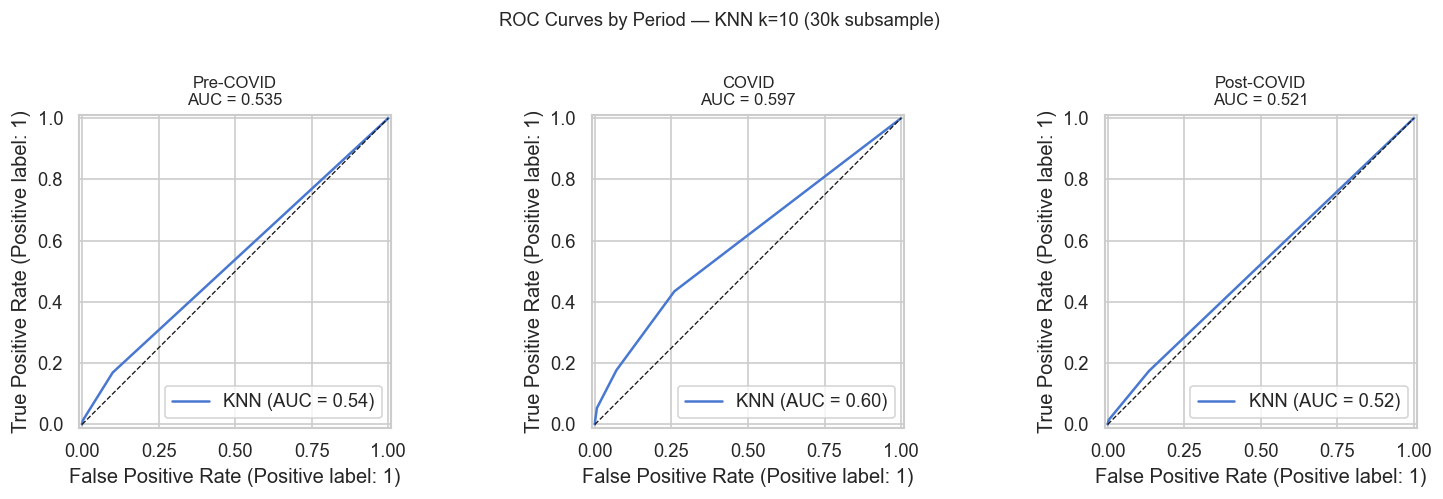


KNN Performance Summary:


,Period,Model,ROC-AUC,PR-AUC,N_test
0,Pre-COVID,KNN (subsample 30k),0.5352,0.0108,185616
1,COVID,KNN (subsample 30k),0.5965,0.0450,55123
2,Post-COVID,KNN (subsample 30k),0.5205,0.0101,201537


In [43]:
# Section 5c — KNN (K-Nearest Neighbors)
# KNN classifies each observation by finding the k most similar training
# observations in feature space and predicting based on their outcomes.
# Here k=10, meaning we look at the 10 nearest neighbors.
# KNN requires scaling because it uses distances — a feature measured in
# tens of thousands (like wage) would completely dominate one measured in
# single digits (like age group dummies) without normalization.
#
# Like SVM, KNN is slow on large datasets because it must compute distances
# to every training point. We apply the same 30,000-row subsample.

from sklearn.neighbors import KNeighborsClassifier

knn_rows = []
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, period in zip(axes, ['Pre-COVID', 'COVID', 'Post-COVID']):
    sub  = model_df[model_df.period == period]
    X    = sub[feature_cols_use].astype(float)
    y    = sub['eu_transition']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Subsample training set to 30,000 rows for computational feasibility
    if len(X_train) > 30000:
        subsample_idx = X_train.sample(n=30000, random_state=42).index
        X_train_sub = X_train.loc[subsample_idx]
        y_train_sub = y_train.loc[subsample_idx]
    else:
        X_train_sub = X_train
        y_train_sub = y_train

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn',    KNeighborsClassifier(n_neighbors=10, n_jobs=-1))
    ])
    pipe.fit(X_train_sub, y_train_sub)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    auc    = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    knn_rows.append({'Period': period, 'Model': 'KNN (subsample 30k)',
                     'ROC-AUC': round(auc, 4), 'PR-AUC': round(pr_auc, 4),
                     'N_test': len(y_test)})

    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name='KNN')
    ax.set_title(f'{period}\nAUC = {auc:.3f}', fontsize=10)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

plt.suptitle('ROC Curves by Period — KNN k=10 (30k subsample)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print('\nKNN Performance Summary:')
display(pd.DataFrame(knn_rows))

In [44]:
# Section 5c — Combined Model Comparison
# Collects all results from Section 5 (Logistic Regression) and 5c
# (LDA, QDA, Decision Tree, Random Forest, Gradient Boosting, SVM, KNN)
# into a single summary table for easy comparison across methods and periods.

all_rows = lda_rows + qda_rows + dt_rows + rf_rows + gb_rows + svm_rows + knn_rows
summary = (
    pd.DataFrame(all_rows)
    .sort_values(['Period', 'ROC-AUC'], ascending=[True, False])
    .reset_index(drop=True)
)

print('Table: All Model Performance by Period (ROC-AUC and PR-AUC)')
display(summary)

# LaTeX version for copy-pasting directly into your paper
print('\nLaTeX table:')
print(summary.to_latex(index=False, float_format='%.4f'))

Table: All Model Performance by Period (ROC-AUC and PR-AUC)


,Period,Model,ROC-AUC,PR-AUC,N_test
0,COVID,Gradient Boosting,0.7413,0.1122,55123
1,COVID,LDA,0.7346,0.1130,55123
2,COVID,QDA,0.7302,0.1033,55123
3,COVID,Decision Tree,0.7278,0.1018,55123
4,COVID,Random Forest,0.7149,0.1029,55123
5,COVID,SVM (subsample 30k),0.6622,0.0504,55123
6,COVID,KNN (subsample 30k),0.5965,0.0450,55123
7,Post-COVID,Gradient Boosting,0.6926,0.0205,201537
8,Post-COVID,LDA,0.6829,0.0191,201537
9,Post-COVID,Decision Tree,0.6767,0.0177,201537



LaTeX table:
\begin{tabular}{llrrr}
\toprule
Period & Model & ROC-AUC & PR-AUC & N_test \\
\midrule
COVID & Gradient Boosting & 0.7413 & 0.1122 & 55123 \\
COVID & LDA & 0.7346 & 0.1130 & 55123 \\
COVID & QDA & 0.7302 & 0.1033 & 55123 \\
COVID & Decision Tree & 0.7278 & 0.1018 & 55123 \\
COVID & Random Forest & 0.7149 & 0.1029 & 55123 \\
COVID & SVM (subsample 30k) & 0.6622 & 0.0504 & 55123 \\
COVID & KNN (subsample 30k) & 0.5965 & 0.0450 & 55123 \\
Post-COVID & Gradient Boosting & 0.6926 & 0.0205 & 201537 \\
Post-COVID & LDA & 0.6829 & 0.0191 & 201537 \\
Post-COVID & Decision Tree & 0.6767 & 0.0177 & 201537 \\
Post-COVID & QDA & 0.6759 & 0.0183 & 201537 \\
Post-COVID & Random Forest & 0.6716 & 0.0193 & 201537 \\
Post-COVID & SVM (subsample 30k) & 0.5935 & 0.0141 & 201537 \\
Post-COVID & KNN (subsample 30k) & 0.5205 & 0.0101 & 201537 \\
Pre-COVID & Gradient Boosting & 0.6806 & 0.0204 & 185616 \\
Pre-COVID & LDA & 0.6733 & 0.0193 & 185616 \\
Pre-COVID & Decision Tree & 0.6653 & 0.0178 &

---
## 6. Industry & Occupation Features

Adds broad IND and OCC category dummies — the biggest available predictive improvement. Compares L2 baseline vs L1-regularized logit with industry/occupation.

Industry distribution:
ind_cat
pub_admin           1955841
wholesale_retail     161971
agri_mining           36150
manufacturing         32966
health_educ           14273
business_svc           6060
construction           4113

Occupation distribution:
occ_cat
educ_legal_arts       397991
healthcare            336682
mgmt                  287570
food_personal_svc     236677
computer_eng_sci      208344
protective_svc        199886
transport_military    144272
sales                 133874
construction_prod     120123
office_admin           73374
business_finance       72581

Baseline features : 15
Extended features : 31  (+16 IND/OCC dummies)
Dataset rows      : 2,211,374

Table 4: Impact of Adding Industry & Occupation Features:


,Period,Model,ROC-AUC,PR-AUC,N_test,EU_rate
0,Pre-COVID,Baseline (L2),0.6753,0.0203,185616,0.0092
1,Pre-COVID,+ IND/OCC (L1),0.6316,0.0190,185616,0.0092
2,COVID,Baseline (L2),0.7347,0.1127,55123,0.0265
3,COVID,+ IND/OCC (L1),0.7464,0.1219,55123,0.0265
4,Post-COVID,Baseline (L2),0.6838,0.0193,201537,0.0093
5,Post-COVID,+ IND/OCC (L1),0.6999,0.0198,201537,0.0093


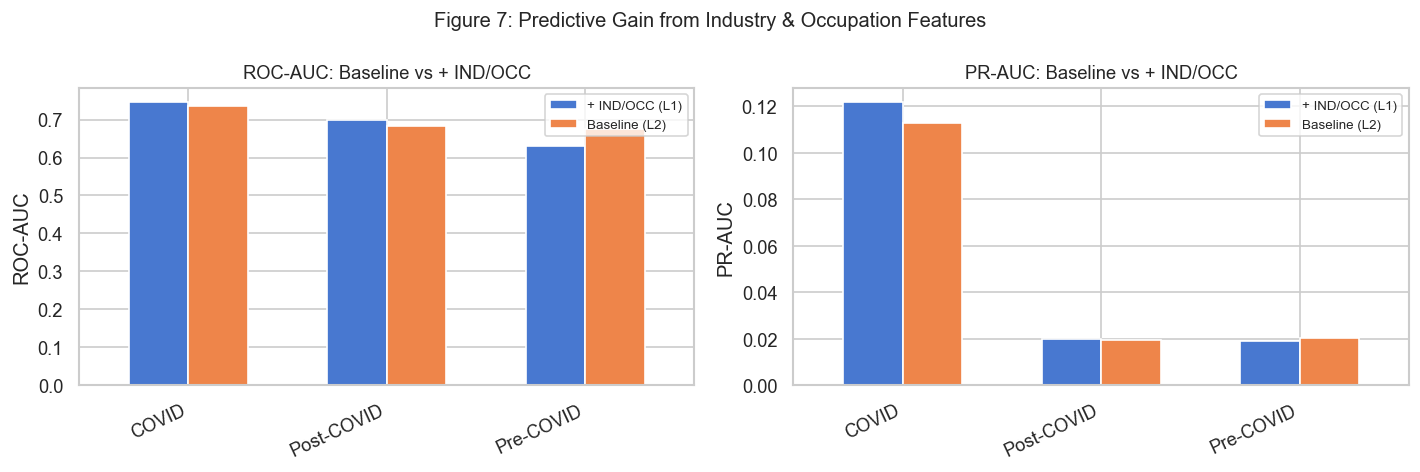


Top IND/OCC L1 coefficients — Post-COVID (non-zero only):
occ_sales                 0.178268
ind_business_svc         -0.161409
ind_pub_admin            -0.158749
occ_transport_military    0.135375
ind_health_educ           0.125458
occ_healthcare            0.121702
occ_construction_prod     0.106706
occ_mgmt                 -0.105477
occ_computer_eng_sci     -0.105454
ind_wholesale_retail     -0.091215
ind_manufacturing        -0.090514
occ_educ_legal_arts       0.076400
ind_construction         -0.044575
occ_office_admin          0.006620
occ_protective_svc        0.006390


In [ ]:
# Section 6: Industry & Occupation Features
# Maps CPS IND/OCC codes to broad categories, adds to logit, compares AUC.

def ind_broad(ind):
    if ind == 0:      return 'missing'
    elif ind < 300:   return 'agri_mining'
    elif ind < 400:   return 'construction'
    elif ind < 700:   return 'manufacturing'
    elif ind < 800:   return 'wholesale_retail'
    elif ind < 900:   return 'transport_comm'
    elif ind < 1000:  return 'finance_fire'
    elif ind < 1100:  return 'business_svc'
    elif ind < 1200:  return 'health_educ'
    else:             return 'pub_admin'

def occ_broad(occ):
    if occ == 0:      return 'missing'
    elif occ < 500:   return 'mgmt'
    elif occ < 800:   return 'business_finance'
    elif occ < 2000:  return 'computer_eng_sci'
    elif occ < 3600:  return 'educ_legal_arts'
    elif occ < 4700:  return 'healthcare'
    elif occ < 5000:  return 'protective_svc'
    elif occ < 6000:  return 'food_personal_svc'
    elif occ < 7000:  return 'sales'
    elif occ < 7700:  return 'office_admin'
    elif occ < 9000:  return 'construction_prod'
    else:             return 'transport_military'

panel['ind_cat'] = panel['IND'].map(ind_broad)
panel['occ_cat'] = panel['OCC'].map(occ_broad)

print('Industry distribution:')
print(panel['ind_cat'].value_counts().to_string())
print('\nOccupation distribution:')
print(panel['occ_cat'].value_counts().to_string())

# Rebuild feature matrix including IND + OCC dummies
educ_d2  = pd.get_dummies(panel['educ_cat'],    prefix='educ', drop_first=False).drop(columns=['educ_hs_diploma'], errors='ignore')
class_d2 = pd.get_dummies(panel['worker_class'], prefix='cls',  drop_first=False).drop(columns=['cls_private'],     errors='ignore')
age_d2   = pd.get_dummies(panel['age_group'],   prefix='age',  drop_first=False).drop(columns=['age_35-44'],       errors='ignore')
ind_d2   = pd.get_dummies(panel['ind_cat'],     prefix='ind',  drop_first=True)
occ_d2   = pd.get_dummies(panel['occ_cat'],     prefix='occ',  drop_first=True)

model_ext = pd.concat([
    panel[['eu_transition', 'period', 'female', 'married', 'part_time']].reset_index(drop=True),
    educ_d2.reset_index(drop=True),
    class_d2.reset_index(drop=True),
    age_d2.reset_index(drop=True),
    ind_d2.reset_index(drop=True),
    occ_d2.reset_index(drop=True),
], axis=1).dropna()

feat_base_ext = [c for c in model_ext.columns
                 if c not in ('eu_transition', 'period')
                 and not c.startswith('ind_') and not c.startswith('occ_')]
feat_full_ext = [c for c in model_ext.columns
                 if c not in ('eu_transition', 'period')]

print(f'\nBaseline features : {len(feat_base_ext)}')
print(f'Extended features : {len(feat_full_ext)}  (+{len(feat_full_ext)-len(feat_base_ext)} IND/OCC dummies)')
print(f'Dataset rows      : {len(model_ext):,}')

# Compare per period
comp_rows = []
for period in ['Pre-COVID', 'COVID', 'Post-COVID']:
    sub = model_ext[model_ext.period == period]
    y   = sub['eu_transition']
    for label, fcols, pen, sol in [
        ('Baseline (L2)',  feat_base_ext, 'l2', 'lbfgs'),
        ('+ IND/OCC (L1)', feat_full_ext, 'l1', 'saga'),
    ]:
        X = sub[fcols].astype(float)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y)
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('logit',  LogisticRegression(penalty=pen, solver=sol, C=1.0,
                       max_iter=1000, class_weight='balanced', random_state=42))
        ])
        pipe.fit(X_tr, y_tr)
        y_prob = pipe.predict_proba(X_te)[:, 1]
        comp_rows.append({
            'Period': period, 'Model': label,
            'ROC-AUC': round(roc_auc_score(y_te, y_prob), 4),
            'PR-AUC':  round(average_precision_score(y_te, y_prob), 4),
            'N_test':  len(y_te), 'EU_rate': round(float(y_te.mean()), 4)
        })

comp_df = pd.DataFrame(comp_rows)
print('\nTable 4: Impact of Adding Industry & Occupation Features:')
display(comp_df)

# Figure 7: Bar chart comparing AUC metrics
fig_cmp, axes_cmp = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes_cmp, ['ROC-AUC', 'PR-AUC']):
    pivot = comp_df.pivot(index='Period', columns='Model', values=metric)
    pivot.plot(kind='bar', ax=ax, color=['#4878d0', '#ee854a'],
               edgecolor='white', width=0.6)
    ax.set_title(f'{metric}: Baseline vs + IND/OCC', fontsize=11)
    ax.set_xlabel(''); ax.set_ylabel(metric)
    ax.legend(fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')

plt.suptitle('Figure 7: Predictive Gain from Industry & Occupation Features', fontsize=12)
plt.tight_layout(); plt.show()

# Top non-zero L1 coefficients for IND/OCC (Post-COVID)
print('\nTop IND/OCC L1 coefficients — Post-COVID (non-zero only):')
sub_post  = model_ext[model_ext.period == 'Post-COVID']
pipe_post = Pipeline([('scaler', StandardScaler()),
                       ('logit', LogisticRegression(penalty='l1', solver='saga',
                        C=1.0, max_iter=1000, class_weight='balanced', random_state=42))])
pipe_post.fit(sub_post[feat_full_ext].astype(float), sub_post['eu_transition'])
coef_s = pd.Series(pipe_post.named_steps['logit'].coef_[0], index=feat_full_ext)
io_coefs = coef_s[[c for c in feat_full_ext if c.startswith('ind_') or c.startswith('occ_')]]
io_coefs = io_coefs[io_coefs != 0].sort_values(key=abs, ascending=False)
print(io_coefs.head(15).to_string())


---
## 7. NILF Robustness Check

The baseline drops E→NILF transitions. Here we include them (coded as 0) to verify that EU rate patterns and predictor rankings are not sensitive to this design choice.

In [ ]:
# Section 7: NILF Robustness Check
# Include E->NILF transitions as eu_transition=0, compare EU rates & rankings.

panel_nilf = cps[
    (cps['emp_group'] == 'employed') &
    (cps['ym_next'] == cps['ym_expected_next'])
].copy()

panel_nilf['eu_transition'] = (panel_nilf['empg_next'] == 'unemployed').astype(int)
panel_nilf['period'] = pd.Categorical(
    panel_nilf['ym'].apply(assign_period),
    categories=['Pre-COVID', 'COVID', 'Post-COVID'], ordered=True
)

nilf_n = (panel_nilf['empg_next'] == 'nilf').sum()
print('Sample sizes:')
print(f'  Baseline  (E->E / E->U only)     : {len(panel):>10,}')
print(f'  With NILF (E->E / E->U / E->NILF): {len(panel_nilf):>10,}')
print(f'  E->NILF transitions added         : {nilf_n:>10,} '
      f'({nilf_n/len(panel_nilf)*100:.2f}% of linked employed rows)')

rate_rows = []
for p in ['Pre-COVID', 'COVID', 'Post-COVID']:
    r_base = panel[panel.period == p]['eu_transition'].mean()
    r_nilf = panel_nilf[panel_nilf.period == p]['eu_transition'].mean()
    rate_rows.append({
        'Period': p,
        'EU Rate (Baseline)':   round(r_base, 4),
        'EU Rate (incl. NILF)': round(r_nilf, 4),
        'Diff (pp)': round((r_nilf - r_base) * 100, 3),
        'N Baseline': len(panel[panel.period == p]),
        'N with NILF': len(panel_nilf[panel_nilf.period == p])
    })

print('\nTable 5: EU Rate — Baseline vs NILF-Included:')
display(pd.DataFrame(rate_rows))

print('\nKey predictor rankings (EU rate by group):')
for var, lbl in [('educ_cat','Education'), ('female','Sex'), ('worker_class','Worker Class')]:
    print(f'\n  {lbl}:')
    for ds_name, ds in [('Baseline', panel), ('With NILF', panel_nilf)]:
        grp = ds.groupby(var, observed=True)['eu_transition'].mean().round(4)
        print(f'    {ds_name}: {grp.to_dict()}')

print('\nConclusion: If rankings above are stable, NILF exclusion is defensible.')


Sample sizes:
  Baseline  (E->E / E->U only)     :  2,211,374
  With NILF (E->E / E->U / E->NILF):  2,270,473
  E->NILF transitions added         :     59,099 (2.60% of linked employed rows)

Table 5: EU Rate — Baseline vs NILF-Included:


,Period,EU Rate (Baseline),EU Rate (incl. NILF),Diff (pp),N Baseline,N with NILF
0,Pre-COVID,0.0092,0.0090,-0.024,928079,952636
1,COVID,0.0265,0.0258,-0.075,275613,283623
2,Post-COVID,0.0093,0.0090,-0.024,1007682,1034214



Key predictor rankings (EU rate by group):

  Education:
    Baseline: {'bachelors': 0.0077, 'graduate': 0.0056, 'hs_diploma': 0.0243, 'lt_hs': 0.022, 'some_college': 0.0135}
    With NILF: {'bachelors': 0.0076, 'graduate': 0.0055, 'hs_diploma': 0.0229, 'lt_hs': 0.021, 'some_college': 0.0131}

  Sex:
    Baseline: {0: 0.0117, 1: 0.0111}
    With NILF: {0: 0.0114, 1: 0.0108}

  Worker Class:
    Baseline: {'government': 0.0083, 'nonprofit': 0.0057, 'other': 0.0257, 'private': 0.0108, 'self_emp': 0.012}
    With NILF: {'government': 0.0081, 'nonprofit': 0.0056, 'other': 0.0249, 'private': 0.0105, 'self_emp': 0.0115}

Conclusion: If rankings above are stable, NILF exclusion is defensible.
